In [33]:
import pandas as pd
ganwon_temp = pd.read_csv('./data/preprocessing/gangwon_temp.csv',encoding='utf-8')
ganwon_elect = pd.read_csv('./data/preprocessing/type_total_elect_gangwon.csv',encoding='utf-8')


In [34]:
# 날씨, 전력 데이터 merge
test_merge = pd.merge(ganwon_temp,ganwon_elect,left_on=['years','지점명','month'], right_on = ['years','지점명','month'],how='inner')
test_merge = test_merge.drop_duplicates()

#결측치 포함 열 제거 
test_merge = test_merge.dropna(how='any',axis=1)
test_merge.isna().sum()
test_merge
test_merge.to_excel('test_merge.xlsx')

In [35]:
test_merge.columns

Index(['Unnamed: 0_x', '지점', '지점명', '일시', '평균기온(°C)', '평균현지기압(hPa)',
       '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)', '월합강수량(00~24h만)(mm)',
       '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)', 'years', 'month',
       'Unnamed: 0_y', '시도', '시군구', '계약종별', '전력량'],
      dtype='str')

In [43]:
test_merge.columns

cor_columns = ['평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)',
       '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)',
       '평균지면온도(°C)','전력량']
corr = test_merge[cor_columns]
corr

,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C),전력량
0,1.8,1019.8,1022.1,3.7,52.0,8.7,2.2,60.79,3.0,1.2,46763124
1,2.4,1018.0,1020.2,4.4,59.0,32.1,2.5,62.81,8.7,2.3,45037434
2,6.6,1017.0,1019.2,5.2,52.0,8.0,2.5,74.49,0.0,8.5,38830684
3,11.1,1014.0,1016.2,8.1,69.0,74.2,2.5,46.87,0.0,12.8,39041260
4,17.8,1005.8,1007.9,11.5,61.0,9.2,2.4,67.60,0.0,23.7,34351238
...,...,...,...,...,...,...,...,...,...,...,...
1072,27.5,992.0,1007.7,27.9,78.0,106.9,1.0,51.33,0.0,30.6,67581225
1073,23.1,998.1,1014.1,22.4,80.0,171.4,0.9,39.33,0.0,25.8,62535720
1074,14.1,1004.4,1021.1,12.9,81.0,106.2,0.7,32.96,0.0,16.7,52157240
1075,7.2,1005.6,1022.9,7.8,75.0,43.3,0.6,45.85,0.0,7.9,56965327


In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# plt.rc("font", family = "Malgun Gothic")
# sns.set(font="Malgun Gothic", 
# rc={"axes.unicode_minus":False}, style='white')

# 한글 폰트 설정 (Mac)
plt.rc('font', family='AppleGothic')
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


In [ ]:

corr_matrix = corr.corr()
corr_matrix


high_corr = corr_matrix[abs(corr_matrix) > 0.5]
high_corr

,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C),전력량
평균기온(°C),1.000000,NaN,-0.922907,0.926407,0.532639,0.580430,NaN,NaN,NaN,0.988762,NaN
평균현지기압(hPa),NaN,1.000000,0.523673,NaN,NaN,NaN,NaN,NaN,NaN,-0.503989,NaN
평균해면기압(hPa),-0.922907,0.523673,1.000000,-0.853367,NaN,-0.527522,NaN,NaN,NaN,-0.934573,NaN
평균수증기압(hPa),0.926407,NaN,-0.853367,1.000000,0.719049,0.684348,NaN,-0.596033,NaN,0.919087,NaN
평균상대습도(%),0.532639,NaN,NaN,0.719049,1.000000,0.549865,NaN,-0.720440,NaN,0.544190,NaN
월합강수량(00~24h만)(mm),0.580430,NaN,-0.527522,0.684348,0.549865,1.000000,NaN,-0.620808,NaN,0.545917,NaN
평균풍속(m/s),NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
일조율(%),NaN,NaN,NaN,-0.596033,-0.720440,-0.620808,NaN,1.000000,NaN,NaN,NaN
최심적설(cm),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
평균지면온도(°C),0.988762,-0.503989,-0.934573,0.919087,0.544190,0.545917,NaN,NaN,NaN,1.000000,NaN


전력량    1.0
Name: 전력량, dtype: float64

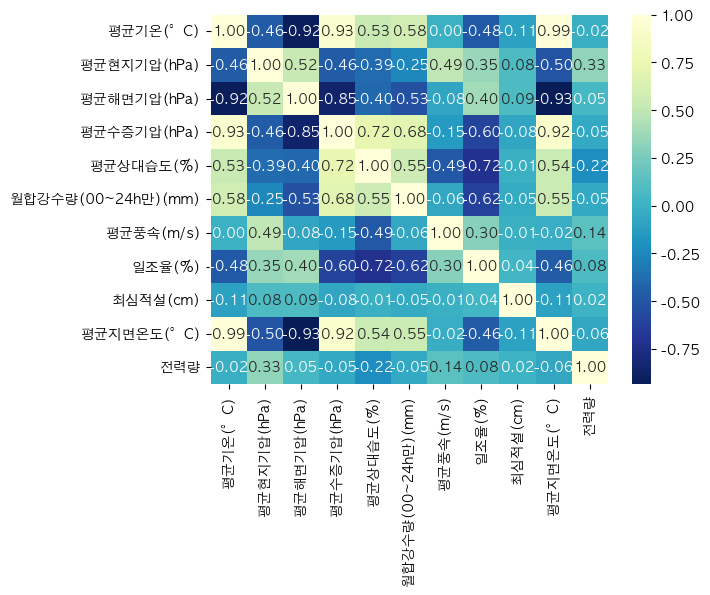

In [48]:
corr_matrix = corr.corr()['전력량']
sns.heatmap(corr.corr(), annot=True, fmt='.2f', cmap='YlGnBu_r')
high_corr = corr_matrix[abs(corr_matrix) > 0.5]
high_corr


In [55]:
from sklearn.tree import DecisionTreeRegressor

X = corr[['평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)',
       '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)',
       '평균지면온도(°C)']]
y = corr['전력량']

tree = DecisionTreeRegressor()
tree.fit(X, y)
tree.score(X,y)

1.0

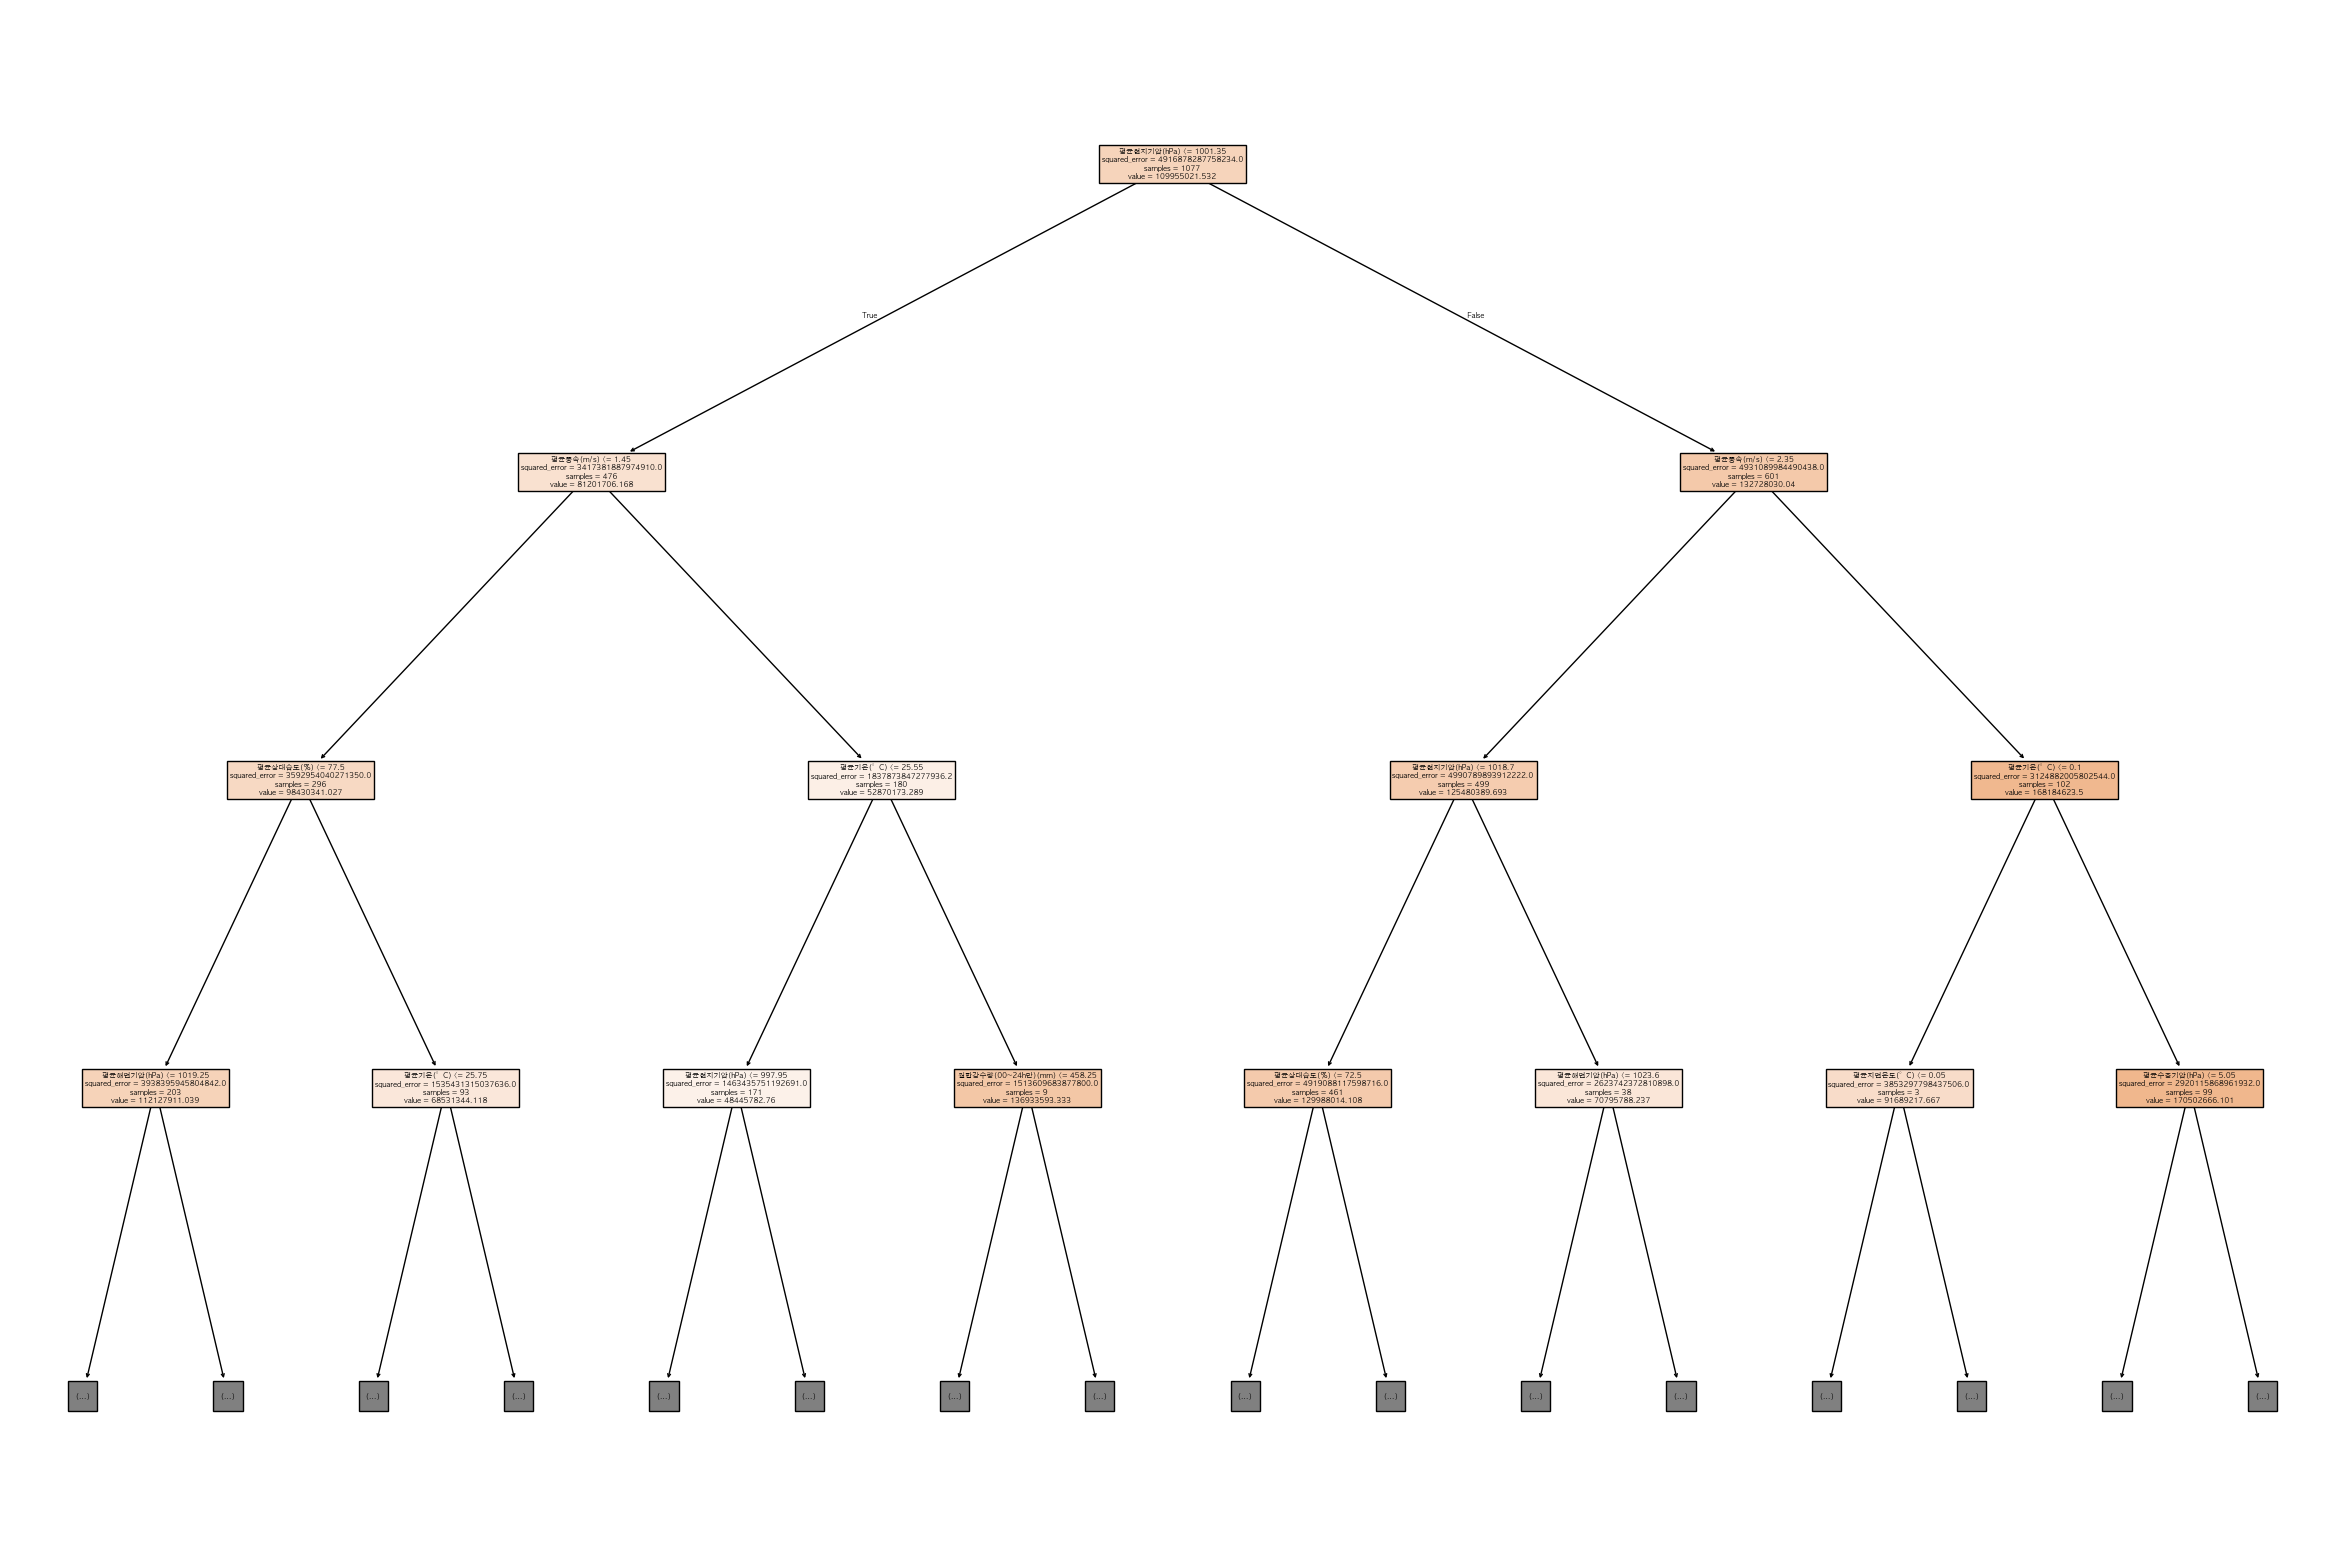

In [56]:
# 3. 트리모델 시각화
from sklearn.tree import plot_tree
# plot_tree(dt_clf)
plt.figure(figsize=(30,20))

plot_tree(tree, filled=True, #색채우기  (특정 클래스의 비율 표현)
          feature_names=X.columns, # feature 이름
          max_depth=3) 
plt.savefig('house.png')
plt.show()